# Pseudobulk Swapping Audit (BRCA2021 dataset) using MMD

- Use RBF-kernel MMD as the primary per-sample quantitative metric.
  Lower MMD ≈ better agreement between the real and generated distributions.


In [1]:
from pathlib import Path
import glob
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

project_root = Path.cwd()
if not (project_root / 'guided_diffusion').exists() and (project_root.parent / 'guided_diffusion').exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from guided_diffusion.cell_datasets_loader import (
    encode_cells_with_vae,
    read_preprocessed_adata,
    read_sample_ids_file,
)


/share/conda-envs/scDiffusion/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Main configuration.
data_dir = '<path/to/data.h5ad>'
vae_path = str(project_root / 'output' / 'checkpoint' / 'AE' / 'brca2021_VAE_alltrain' / 'model_seed=1234_step=199999.pt')
generated_glob = str(project_root / 'output' / 'simulated_samples' / 'brca2021_pseudobulk_1M_alltrain_*.npz')

# Paths to train/test split files produced by make_brca2021_subtype_splits.py.
# Both are optional; when provided the summary plot separates the two splits.
train_sample_ids_path = str(project_root / 'output' / 'sample_splits' / 'brca2021_manual' / 'train_samples.txt')
test_sample_ids_path  = str(project_root / 'output' / 'sample_splits' / 'brca2021_manual' / 'test_samples.txt')

sample_key = 'SampleID'
random_seed = 1234

# MMD is quadratic in cell count, so we cap each sample for the metric.
max_cells_for_mmd = 1200
encode_batch_size = 1024

# UMAP view for one chosen sample.
focus_sample_id = ''
max_cells_for_umap_per_group = 2500

generated_glob

The MMD below is computed in VAE latent space. This keeps the comparison aligned with the space the diffusion model actually learned to generate in, while still comparing full cell distributions rather than pseudobulk summaries.

In [3]:
# Import shared MMD utilities from the project library.
from guided_diffusion.pseudobulk_mmd_eval import compute_mmd_summary, subsample_rows


def scalar_from_npz(value):
    """Extract a Python scalar from a 0-d or 1-element numpy array."""
    value = np.asarray(value)
    if value.shape == ():
        return value.item()
    flat = value.reshape(-1)
    return flat[0].item() if hasattr(flat[0], 'item') else flat[0]


def to_numpy_dense(matrix):
    """Convert a sparse or dense matrix to a float32 numpy array."""
    if hasattr(matrix, 'toarray'):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def paired_subsamples_for_real_baseline(matrix, max_rows_per_group, seed=1234):
    """Split *matrix* into two random halves for a same-sample MMD baseline."""
    matrix = np.asarray(matrix, dtype=np.float32)
    total_rows = min(matrix.shape[0], max_rows_per_group * 2)
    if total_rows < 4:
        return matrix[:0], matrix[:0]
    rng = np.random.default_rng(seed)
    idx = rng.choice(matrix.shape[0], size=total_rows, replace=False)
    idx = rng.permutation(idx)
    half = total_rows // 2
    return matrix[idx[:half]], matrix[idx[half:half + half]]


def discover_generated_paths(pattern):
    """Return a sorted list of Paths matching *pattern*."""
    return sorted(Path(path) for path in glob.glob(pattern))


In [4]:
generated_paths = discover_generated_paths(generated_glob)
train_ids = read_sample_ids_file(train_sample_ids_path)
test_ids  = read_sample_ids_file(test_sample_ids_path)

# Collect all SampleIDs present in the generated files.
generated_sample_ids = sorted(
    {str(scalar_from_npz(np.load(p, allow_pickle=True)['source_sample_id']))
     for p in generated_paths}
)

# Restrict evaluation to samples that appear in either split file.
known_ids = set()
if train_ids is not None:
    known_ids |= set(train_ids)
if test_ids is not None:
    known_ids |= set(test_ids)

if known_ids:
    evaluated_sample_ids = [sid for sid in generated_sample_ids if sid in known_ids]
    split_mode = 'train_and_test'
else:
    evaluated_sample_ids = generated_sample_ids
    split_mode = 'all_generated_samples'


def sample_split_label(sample_id):
    """Return 'test', 'train', or 'unknown' for *sample_id*."""
    if test_ids is not None and sample_id in test_ids:
        return 'test'
    if train_ids is not None and sample_id in train_ids:
        return 'train'
    return 'unknown'


print('generated files found:', len(generated_paths))
print('generated SampleIDs on disk:', len(generated_sample_ids))
print('evaluation scope:', split_mode)
print('samples selected for evaluation:', len(evaluated_sample_ids))
print('train split file provided:', train_ids is not None)
print('test split file provided:', test_ids is not None)
print('first few SampleIDs:', evaluated_sample_ids[:10])


generated files found: 26
generated SampleIDs on disk: 26
evaluation scope: train_and_test
samples selected for evaluation: 26
train split file provided: True
test split file provided: True
first few SampleIDs: ['CID3586', 'CID3838', 'CID3921', 'CID3941', 'CID3946', 'CID3948', 'CID3963', 'CID4040', 'CID4066', 'CID4067']


In [5]:
adata = read_preprocessed_adata(data_dir)
print('preprocessed dataset shape:', adata.shape)
print('available real SampleIDs:', adata.obs[sample_key].astype(str).nunique())


preprocessed dataset shape: (99526, 25209)
available real SampleIDs: 26


For each generated `.npz` file, the notebook:
- looks up the corresponding real sample in the BRCA2021 AnnData
- encodes the real cells into the same VAE latent space
- compares real and generated latent cell clouds with RBF-kernel MMD

This is a distribution-vs-distribution comparison, so it does not require 1:1 cell matching.

In [6]:
summary_rows = []
latent_payload_by_sample = {}

for path in generated_paths:
    with np.load(path, allow_pickle=True) as npzfile:
        sample_id = str(scalar_from_npz(npzfile['source_sample_id']))
        if sample_id not in evaluated_sample_ids:
            continue

        generated_latent = np.asarray(npzfile['cell_gen'], dtype=np.float32)
        real_num_cells_stored = int(scalar_from_npz(npzfile['real_num_cells']))

    sample_mask = adata.obs[sample_key].astype(str).to_numpy() == sample_id
    if not sample_mask.any():
        print(f'skipping {sample_id}: no real cells found after preprocessing')
        continue

    real_gene = to_numpy_dense(adata[sample_mask].X)
    real_latent = encode_cells_with_vae(
        real_gene,
        vae_path=vae_path,
        hidden_dim=128,
        encode_batch_size=encode_batch_size,
    )

    real_latent_mmd = subsample_rows(real_latent, max_cells_for_mmd, seed=random_seed)
    generated_latent_mmd = subsample_rows(generated_latent, max_cells_for_mmd, seed=random_seed)
    mmd_summary = compute_mmd_summary(real_latent_mmd, generated_latent_mmd)
    real_a, real_b = paired_subsamples_for_real_baseline(real_latent, max_cells_for_mmd, seed=random_seed)
    real_real_summary = compute_mmd_summary(real_a, real_b) if min(real_a.shape[0], real_b.shape[0]) >= 2 else {
        'latent_mmd_rbf': np.nan,
        'latent_mmd_sigma': np.nan,
        'latent_mmd_kernel_count': 0,
    }

    summary_rows.append({
        'sample_id': sample_id,
        'num_real_cells': int(real_gene.shape[0]),
        'num_generated_cells': int(generated_latent.shape[0]),
        'stored_real_num_cells': real_num_cells_stored,
        'mmd_eval_real_cells': int(real_latent_mmd.shape[0]),
        'mmd_eval_generated_cells': int(generated_latent_mmd.shape[0]),
        'latent_mmd_rbf': mmd_summary['latent_mmd_rbf'],
        'latent_mmd_sigma': mmd_summary['latent_mmd_sigma'],
        'real_vs_real_mmd_rbf': real_real_summary['latent_mmd_rbf'],
        'sample_split': sample_split_label(sample_id),
        'generated_path': str(path.relative_to(project_root)),
    })

    latent_payload_by_sample[sample_id] = {
        'real_latent': real_latent,
        'generated_latent': generated_latent,
        'real_centroid': np.asarray(real_latent, dtype=np.float32).mean(axis=0),
    }

summary_df = pd.DataFrame(summary_rows)
if len(summary_df) > 0:
    nearest_other_ids = []
    nearest_other_mmds = []
    sample_ids_in_summary = summary_df['sample_id'].tolist()
    for sample_id in sample_ids_in_summary:
        current_payload = latent_payload_by_sample[sample_id]
        other_ids = [other_id for other_id in sample_ids_in_summary if other_id != sample_id]
        if not other_ids:
            nearest_other_ids.append(None)
            nearest_other_mmds.append(np.nan)
            continue

        nearest_other_id = min(
            other_ids,
            key=lambda other_id: float(np.linalg.norm(current_payload['real_centroid'] - latent_payload_by_sample[other_id]['real_centroid'])),
        )
        current_real_latent = subsample_rows(current_payload['real_latent'], max_cells_for_mmd, seed=random_seed)
        other_real_latent = subsample_rows(latent_payload_by_sample[nearest_other_id]['real_latent'], max_cells_for_mmd, seed=random_seed)
        other_summary = compute_mmd_summary(current_real_latent, other_real_latent)
        nearest_other_ids.append(nearest_other_id)
        nearest_other_mmds.append(other_summary['latent_mmd_rbf'])

    summary_df['nearest_other_sample_id'] = nearest_other_ids
    summary_df['real_vs_other_sample_mmd_rbf'] = nearest_other_mmds
    summary_df = summary_df.sort_values('latent_mmd_rbf').reset_index(drop=True)
summary_df


,sample_id,num_real_cells,num_generated_cells,stored_real_num_cells,mmd_eval_real_cells,mmd_eval_generated_cells,latent_mmd_rbf,latent_mmd_sigma,real_vs_real_mmd_rbf,sample_split,generated_path,nearest_other_sample_id,real_vs_other_sample_mmd_rbf
0,CID3941,623,623,623,623,623,0.000006,0.490521,4.548208e-04,train,output/simula...,CID3921,0.040740
1,CID4066,5298,5298,5298,1200,1200,0.000049,0.520110,-6.632675e-05,train,output/simula...,CID3921,0.021646
2,CID3921,3016,3016,3016,1200,1200,0.000086,0.475611,-2.983402e-05,train,output/simula...,CID4066,0.021646
3,CID4465,1552,1552,1552,1200,1200,0.000113,0.597698,-1.508427e-04,train,output/simula...,CID4461,0.030339
4,CID4471,8550,8550,8550,1200,1200,0.000152,0.427294,-1.368141e-04,train,output/simula...,CID4066,0.061838
5,CID3838,2346,2346,2346,1200,1200,0.000153,0.384063,-1.667635e-04,train,output/simula...,CID4040,0.033052
6,CID4040,2522,2522,2522,1200,1200,0.000171,0.393991,-2.526941e-07,train,output/simula...,CID3838,0.033052
7,CID4461,629,629,629,629,629,0.000181,0.594501,1.436196e-04,train,output/simula...,CID4465,0.030339
8,CID4398,4440,4440,4440,1200,1200,0.000252,0.412939,-2.113261e-05,train,output/simula...,CID44041,0.096802
9,CID4495,7893,7893,7893,1200,1200,0.000272,0.444954,-1.133216e-04,train,output/simula...,CID44971,0.035553


`latent_mmd_rbf` is the main score in this notebook.

- lower is better
- `0` would mean the two distributions are indistinguishable under the chosen kernel
- `real_vs_real_mmd_rbf` is a same-sample baseline obtained by splitting the real sample into two random halves
- `real_vs_other_sample_mmd_rbf` is a mismatched-sample baseline using the closest wrong real sample in latent-centroid space
- good generated samples should usually sit closer to `real_vs_real_mmd_rbf` than to `real_vs_other_sample_mmd_rbf`
- values should be compared across held-out samples from the same workflow, preprocessing, latent space, and kernel setup


In [7]:
summary_df[['sample_id', 'sample_split', 'num_real_cells', 'num_generated_cells', 'latent_mmd_rbf', 'real_vs_real_mmd_rbf', 'real_vs_other_sample_mmd_rbf', 'nearest_other_sample_id', 'latent_mmd_sigma']]


,sample_id,sample_split,num_real_cells,num_generated_cells,latent_mmd_rbf,real_vs_real_mmd_rbf,real_vs_other_sample_mmd_rbf,nearest_other_sample_id,latent_mmd_sigma
0,CID3941,train,623,623,0.000006,4.548208e-04,0.040740,CID3921,0.490521
1,CID4066,train,5298,5298,0.000049,-6.632675e-05,0.021646,CID3921,0.520110
2,CID3921,train,3016,3016,0.000086,-2.983402e-05,0.021646,CID4066,0.475611
3,CID4465,train,1552,1552,0.000113,-1.508427e-04,0.030339,CID4461,0.597698
4,CID4471,train,8550,8550,0.000152,-1.368141e-04,0.061838,CID4066,0.427294
5,CID3838,train,2346,2346,0.000153,-1.667635e-04,0.033052,CID4040,0.384063
6,CID4040,train,2522,2522,0.000171,-2.526941e-07,0.033052,CID3838,0.393991
7,CID4461,train,629,629,0.000181,1.436196e-04,0.030339,CID4465,0.594501
8,CID4398,train,4440,4440,0.000252,-2.113261e-05,0.096802,CID44041,0.412939
9,CID4495,train,7893,7893,0.000272,-1.133216e-04,0.035553,CID44971,0.444954


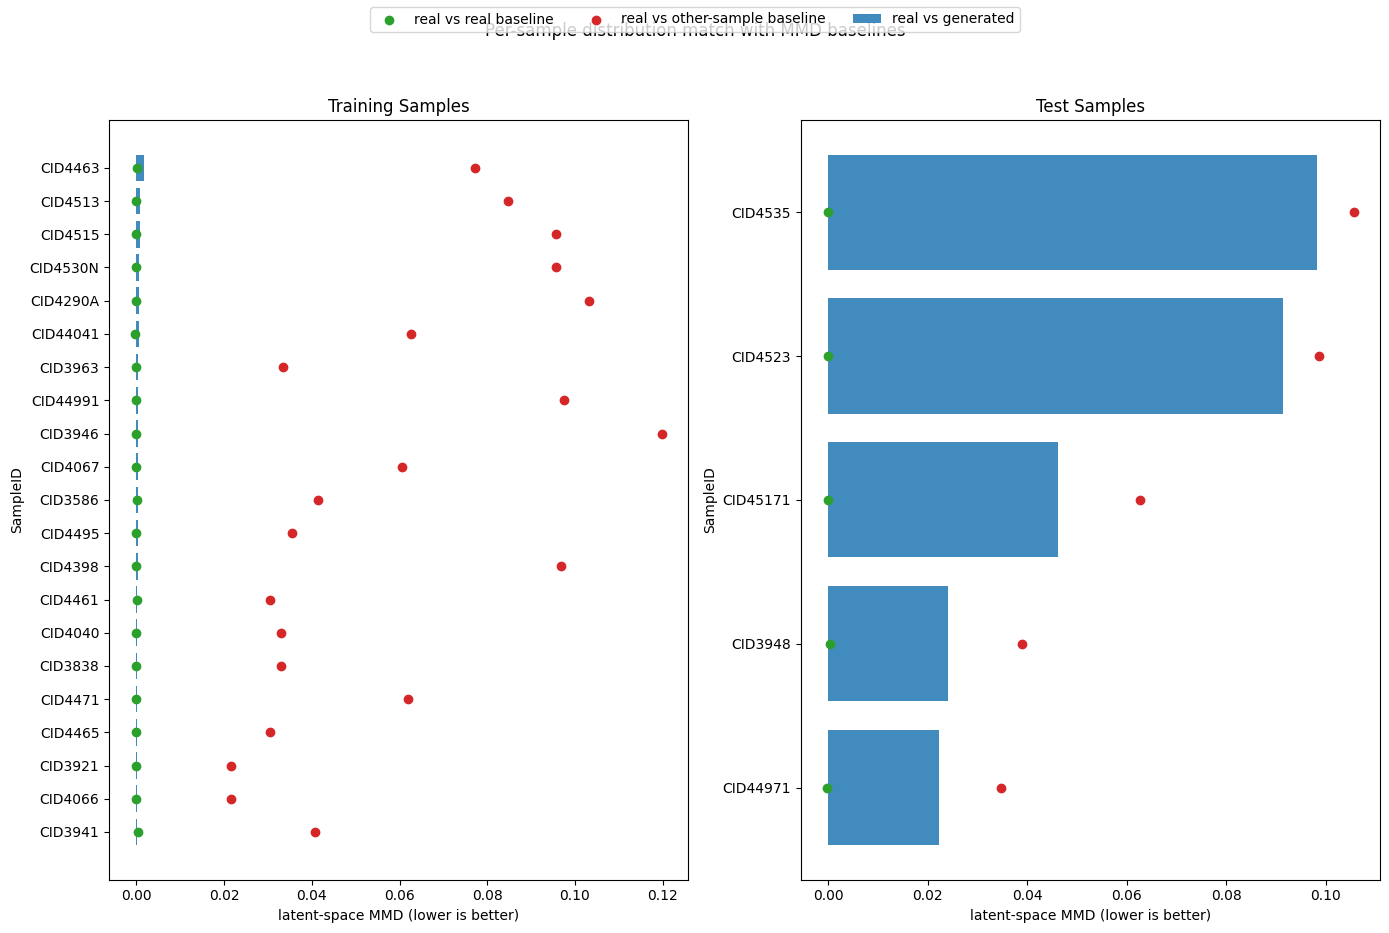

In [8]:
if len(summary_df) == 0:
    print('No samples were evaluated. Check generated_glob, train_sample_ids_path, and test_sample_ids_path.')
else:
    summary_df[['latent_mmd_rbf', 'real_vs_real_mmd_rbf', 'real_vs_other_sample_mmd_rbf']].describe()

    def plot_mmd_panel(ax, panel_df, title):
        if len(panel_df) == 0:
            ax.set_title(title)
            ax.text(0.5, 0.5, 'No generated samples available', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            return

        plot_df = panel_df.sort_values('latent_mmd_rbf')
        y = np.arange(len(plot_df))
        ax.barh(y, plot_df['latent_mmd_rbf'], alpha=0.85, label='real vs generated')
        ax.scatter(plot_df['real_vs_real_mmd_rbf'], y, color='tab:green', label='real vs real baseline', zorder=3)
        ax.scatter(plot_df['real_vs_other_sample_mmd_rbf'], y, color='tab:red', label='real vs other-sample baseline', zorder=3)
        ax.set_yticks(y, plot_df['sample_id'])
        ax.set_xlabel('latent-space MMD (lower is better)')
        ax.set_ylabel('SampleID')
        ax.set_title(title)

    if test_ids is not None:
        train_like_mask = summary_df['sample_split'].isin(['train', 'unknown'])
        heldout_mask = summary_df['sample_split'] == 'test'
        train_label = 'Training Samples'
        if train_ids is None:
            train_label = 'Non-test Generated Samples'

        fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.35 * max(len(summary_df[train_like_mask]), len(summary_df[heldout_mask])) + 2)), sharex=False)
        plot_mmd_panel(axes[0], summary_df[train_like_mask], train_label)
        plot_mmd_panel(axes[1], summary_df[heldout_mask], 'Test Samples')
        handles, labels = axes[0].get_legend_handles_labels()
        if not handles:
            handles, labels = axes[1].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper center', ncol=3)
        fig.suptitle('Per-sample distribution match with MMD baselines')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
    else:
        fig, ax = plt.subplots(1, 1, figsize=(8, 0.35 * len(summary_df) + 2))
        plot_mmd_panel(ax, summary_df, 'Generated-vs-real sample distribution match')
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend()
        plt.tight_layout()
        plt.show()
